# Initial Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, ParameterGrid
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                             log_loss, confusion_matrix, ConfusionMatrixDisplay)

from imblearn.pipeline import Pipeline          
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from IPython.display import display


bank = pd.read_csv('../data/Churn.csv')
print(bank.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.1 MB
None


In [3]:
# Formatting columns.

new_columns = [column.strip().lower() for column in bank.columns]
bank.columns = new_columns
print(bank.columns)

Index(['rownumber', 'customerid', 'surname', 'creditscore', 'geography',
       'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'exited'],
      dtype='str')


In [4]:
# Filling NaN values.

median_tenure = bank[~bank['tenure'].isna()]['tenure'].median()
bank['tenure'] = bank['tenure'].fillna(median_tenure)
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rownumber        10000 non-null  int64  
 1   customerid       10000 non-null  int64  
 2   surname          10000 non-null  str    
 3   creditscore      10000 non-null  int64  
 4   geography        10000 non-null  str    
 5   gender           10000 non-null  str    
 6   age              10000 non-null  int64  
 7   tenure           10000 non-null  float64
 8   balance          10000 non-null  float64
 9   numofproducts    10000 non-null  int64  
 10  hascrcard        10000 non-null  int64  
 11  isactivemember   10000 non-null  int64  
 12  estimatedsalary  10000 non-null  float64
 13  exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.1 MB


In [5]:
# Removing columns that are not considered necessary for the analysis.

bank = bank.drop(["customerid",'rownumber', 'surname'], axis=1)
bank.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [6]:
# Checking for duplicates.

bank.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

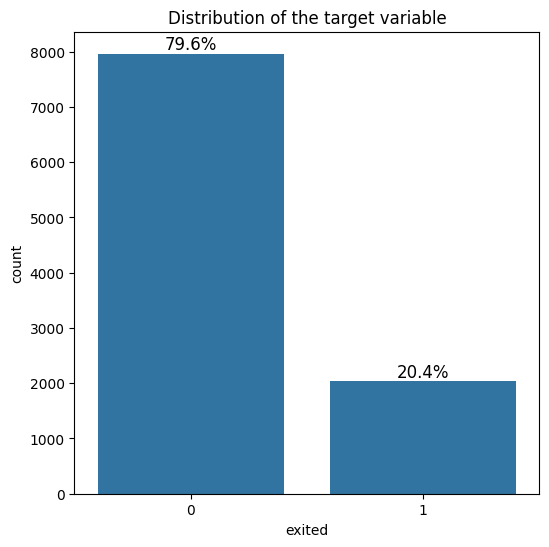

In [7]:
# Analysing distribution of the target variable.

plt.figure(figsize=(6, 6))
ax = sns.countplot(x='exited', data=bank)
plt.title('Distribution of the target variable')

total = len(bank)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12)

plt.show()

The dataset is imbalanced, with approximately 80% of customers not churning and 20% churning. This ratio means a naive model could achieve 80% accuracy simply by predicting no one churns, making accuracy a misleading metric for this problem. It also directly motivates the use of sampling strategies during training and the choice to prioritize F1 and ROC-AUC over accuracy when evaluating model performance.

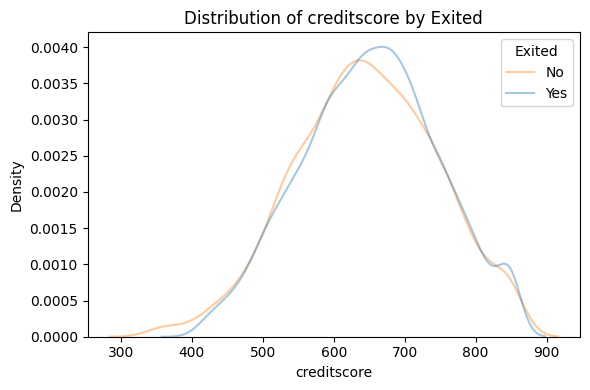

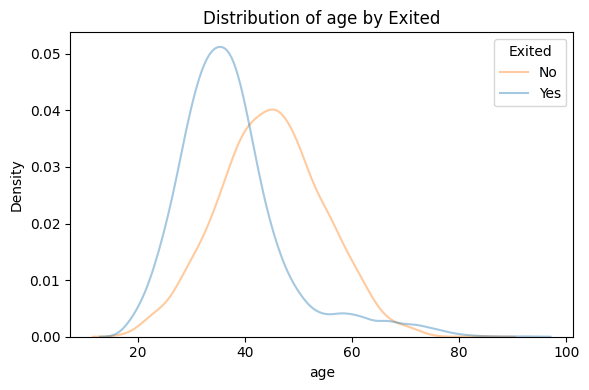

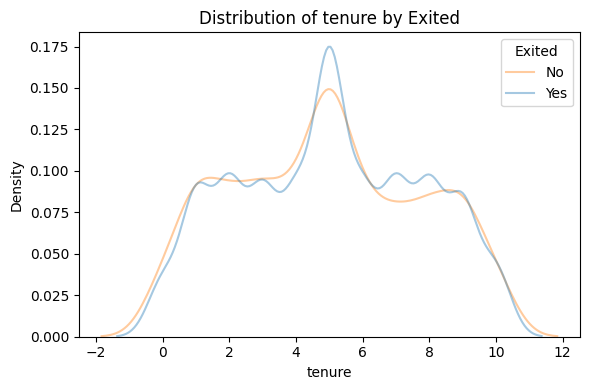

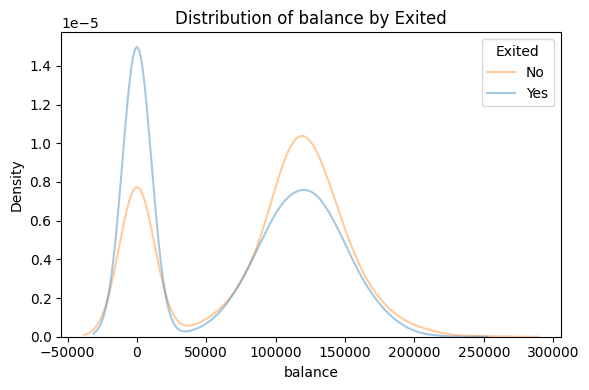

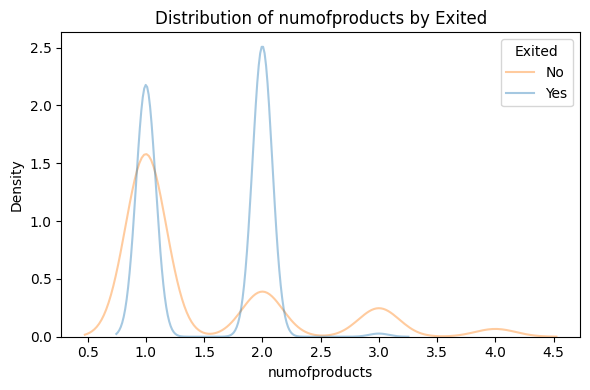

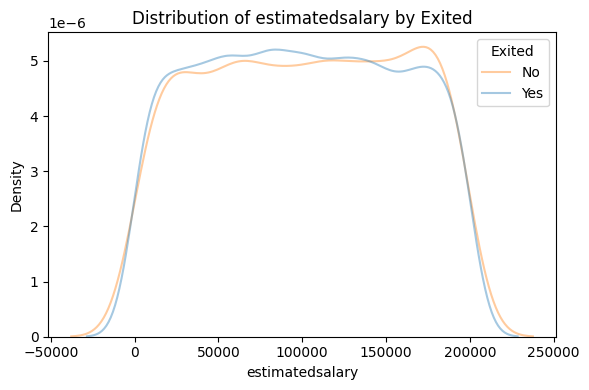

In [8]:
# Analysing the distrubution of numerical variables.

numerical_cols = ['creditscore', 'age', 'tenure', 'balance', 'numofproducts', 'estimatedsalary']

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=bank, x=col, hue='exited',
                common_norm=False, alpha=0.4)
    plt.title(f'Distribution of {col} by Exited')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend(title='Exited', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()  

Most numerical variables show limited separation between churners and non-churners, with three clear exceptions.

Age stands out as the strongest signal: churners are concentrated around 35–40, while non-churners extend toward older ages. This suggests churned customers tend to be relatively younger.

Balance shows a clear pattern: non-churners cluster at zero balance, while churners are more common in the 100k–150k range, possibly indicating greater sensitivity to competing offers.

Number of products shows the sharpest separation: customers with 2 products are highly concentrated among churners, while those with 1 product are more evenly distributed, suggesting a non-linear relationship with churn.

In [9]:
# Analyzing the relationship between categorical contract features and churn.

categorical_cols = ['geography', 'gender', 'hascrcard', 'isactivemember']


for col in categorical_cols:
    dist = bank.groupby(col)['exited'].agg(['mean', 'count'])
    dist = dist.sort_values(by="mean", ascending=False)
    
    display_df = pd.DataFrame(dist.values, columns=[
                              'Proportion', 'Count'], index=dist.index)

    display_df['Proportion'] = display_df['Proportion'].apply(lambda x: f"{x:.2%}")
    display_df['Count'] = display_df['Count'].astype(int)
    
    display_df.index.name = None

    print(f"\nChurn rate for {col}:")
    display(display_df)


Churn rate for geography:


,Proportion,Count
Germany,32.44%,2509
Spain,16.67%,2477
France,16.15%,5014



Churn rate for gender:


,Proportion,Count
Female,25.07%,4543
Male,16.46%,5457



Churn rate for hascrcard:


,Proportion,Count
0,20.81%,2945
1,20.18%,7055



Churn rate for isactivemember:


,Proportion,Count
0,26.85%,4849
1,14.27%,5151


The categorical features reveal clear and actionable differences in churn behavior. Geography emerges as a strong driver, with customers in Germany churning at roughly double the rate of those in France and Spain. Customer activity is even more impactful, as inactive members churn at significantly higher rates, making it one of the most important predictors of retention. Gender also provides meaningful signal, with female customers showing higher churn compared to male customers. In contrast, having a credit card shows almost no difference between groups and is unlikely to contribute much predictive value on its own.

Overall, customer activity and geography stand out as the dominant categorical factors, while the remaining features offer limited additional signal.

# Machine Learning

In [10]:
X = bank.drop('exited', axis=1)
y = bank['exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12345, stratify=y
)

The dataset is split into 80% training and 20% test sets. The stratify=y argument ensures that both sets preserve the same proportion of churners as the original dataset. Since the data is imbalanced, skipping this could cause the split to accidentally concentrate most churners in one set, making training or evaluation unreliable.

In [11]:
cat_cols = ['geography', 'gender']
num_cols = ['creditscore', 'age', 'tenure', 'balance',
            'estimatedsalary', 'numofproducts', 'hascrcard', 'isactivemember']

preprocessor_lr = ColumnTransformer([
    ('ohe',    OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('scaler', StandardScaler(), num_cols)
])

preprocessor_rf = ColumnTransformer([
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', 'passthrough', num_cols)
])


Two separate preprocessors are defined because each model has different requirements. Logistic Regression is a linear model sensitive to both how categories are encoded and the scale of numerical features, so it uses One-Hot Encoding to avoid implying any ordinal relationship between categories, and StandardScaler to bring all numerical features onto the same scale. Random Forest, being a tree-based model, is invariant to feature scale and handles integer-encoded categories naturally, so it uses Ordinal Encoding and passes numerical features through without scaling.

In [12]:
def make_pipelines(preprocessor, model):
    raw = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    up = Pipeline([
        ('preprocessor', preprocessor),
        ('sampler', RandomOverSampler(random_state=12345)),
        ('model', model)
    ])
    down = Pipeline([
        ('preprocessor', preprocessor),
        ('sampler', RandomUnderSampler(random_state=12345)),
        ('model', model)
    ])
    
    return raw, up, down

Each model is wrapped in a pipeline that chains preprocessing, sampling, and the model itself into a single object. The key reason for this is data integrity: by placing the sampler inside the pipeline, oversampling and undersampling only occur on the training data, never touching the test set. If resampling had been applied before splitting, synthetic samples could have leaked into the test set, producing inflated and misleading evaluation metrics.

In [13]:
def train_with_search(model, param_grid,
                      X_train, X_test,
                      y_train, y_test,
                      model_name='Model',
                      iterations=10,
                      n_splits=5):

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    total_params = len(ParameterGrid(param_grid))
    actual_iter = min(iterations, total_params)

    search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=actual_iter,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    prediction = best_model.predict(X_test)
    probas = best_model.predict_proba(X_test)[:, 1]

    results = {
        'F1 Score': f1_score(y_test, prediction),
        'ROC AUC':  roc_auc_score(y_test, probas),
        'Accuracy': accuracy_score(y_test, prediction),
        'Log Loss': log_loss(y_test, probas)
    }

    print(f"\nBest {model_name} Performance:")
    display(pd.DataFrame(results.values(),
            index=results.keys(), columns=['Score']))

    print("\nBest params:")
    display(pd.DataFrame(search.best_params_, index=[
            0]).T.rename(columns={0: 'Best Value'}))

    ConfusionMatrixDisplay(confusion_matrix(y_test, prediction)).plot()
    plt.title(f'Confusion Matrix — {model_name}')
    plt.show()

    return results, search.best_params_, best_model

This function handles training, hyperparameter search, and evaluation in one reusable block. It takes a model and a parameter grid as inputs and runs a randomized search to find the best combination of hyperparameters, making it easy to apply the same process to every model without repeating code.


## Dummy (Baseline)

In [14]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=12345)
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)
dummy_probas = dummy.predict_proba(X_test)[:, 1]

results_dummy = {
    'F1 Score': f1_score(y_test, dummy_pred),
    'ROC AUC':  roc_auc_score(y_test, dummy_probas),
    'Accuracy': accuracy_score(y_test, dummy_pred),
    'Log Loss': log_loss(y_test, dummy_probas)
}

display(pd.DataFrame(results_dummy.values(),
        index=results_dummy.keys(), columns=['Score']))

,Score
F1 Score,0.000000
ROC AUC,0.500000
Accuracy,0.796500
Log Loss,7.334883


The dummy classifier always predicts the majority class, serving as the minimum performance bar any real model must surpass. Despite achieving 79.6% accuracy, it completely fails to identify a single churner, producing an F1 of 0 and a ROC-AUC of 0.5, equivalent to a coin flip. This confirms that accuracy alone is a deceptive metric in this context and validates the decision to evaluate models primarily on F1 and ROC-AUC.

## Logistic Regression

── Logistic Regression Raw ──

Best LR – Raw Performance:


,Score
F1 Score,0.509771
ROC AUC,0.781850
Accuracy,0.711500
Log Loss,0.581437



Best params:


,Best Value
model__class_weight,balanced
model__C,0.01


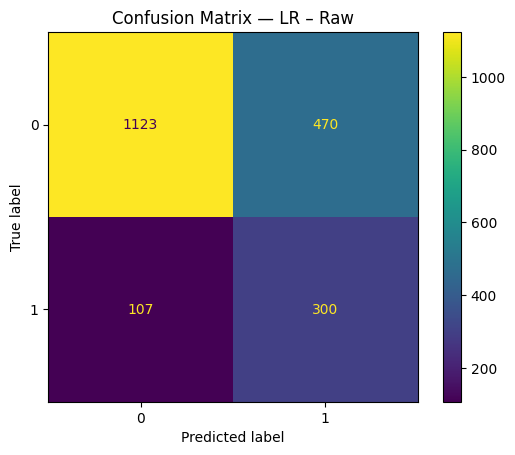

── Logistic Regression Upsampled ──

Best LR – Upsampled Performance:


,Score
F1 Score,0.511548
ROC AUC,0.782389
Accuracy,0.714500
Log Loss,0.579916



Best params:


,Best Value
model__class_weight,balanced
model__C,1


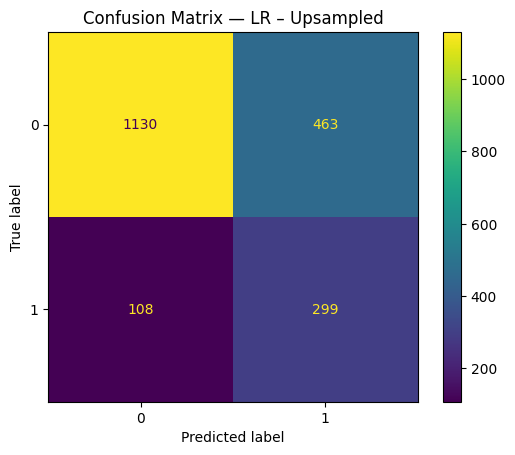

── Logistic Regression Downsampled ──

Best LR – Downsampled Performance:


,Score
F1 Score,0.512777
ROC AUC,0.781379
Accuracy,0.714000
Log Loss,0.580427



Best params:


,Best Value
model__class_weight,balanced
model__C,0.1


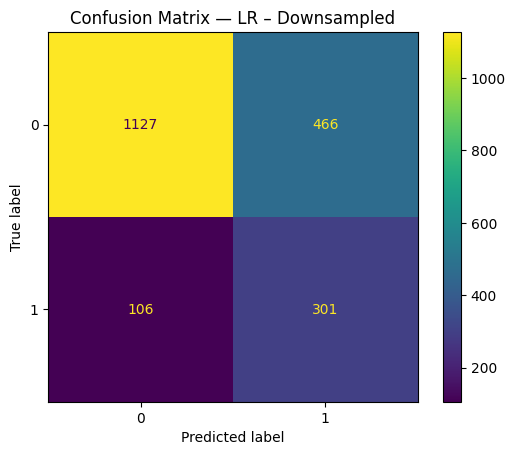

In [15]:
lr_raw, lr_up, lr_down = make_pipelines(
    preprocessor_lr,
    LogisticRegression(solver='liblinear', random_state=54321)
)

param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': ['balanced', None]
}

print("── Logistic Regression Raw ──")
lr_raw_results, lr_raw_params, lr_raw_best = train_with_search(
    lr_raw, param_grid_lr, X_train, X_test, y_train, y_test, model_name='LR – Raw')

print("── Logistic Regression Upsampled ──")
lr_up_results, lr_up_params, lr_up_best = train_with_search(
    lr_up, param_grid_lr, X_train, X_test, y_train, y_test, model_name='LR – Upsampled')

print("── Logistic Regression Downsampled ──")
lr_down_results, lr_down_params, lr_down_best = train_with_search(
    lr_down, param_grid_lr, X_train, X_test, y_train, y_test, model_name='LR – Downsampled')

All three Logistic Regression variants perform similarly regardless of sampling strategy, with F1 scores clustered around 0.51 and ROC-AUC around 0.78. This consistency suggests the model has reached its ceiling and the sampling method is not the limiting factor. The underlying issue is that Logistic Regression assumes a linear decision boundary, which is likely too simple to capture the relationships in this dataset.

## Random Forest Classifier

── Random Forest Raw ──

Best RF – Raw Performance:


,Score
F1 Score,0.628370
ROC AUC,0.864725
Accuracy,0.841500
Log Loss,0.392993



Best params:


,Best Value
model__n_estimators,200
model__max_depth,10
model__class_weight,balanced


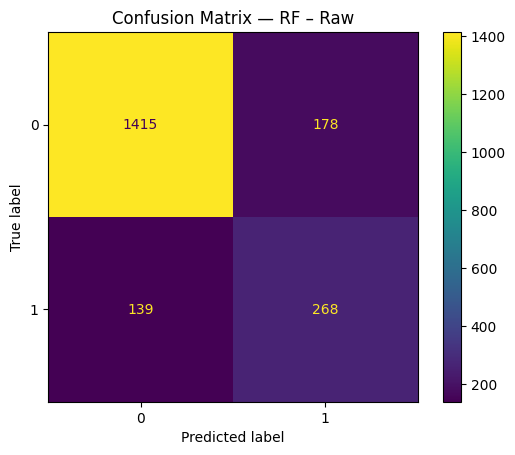

── Random Forest Upsampled ──

Best RF – Upsampled Performance:


,Score
F1 Score,0.636364
ROC AUC,0.863289
Accuracy,0.832000
Log Loss,0.414623



Best params:


,Best Value
model__n_estimators,200
model__max_depth,10
model__class_weight,balanced


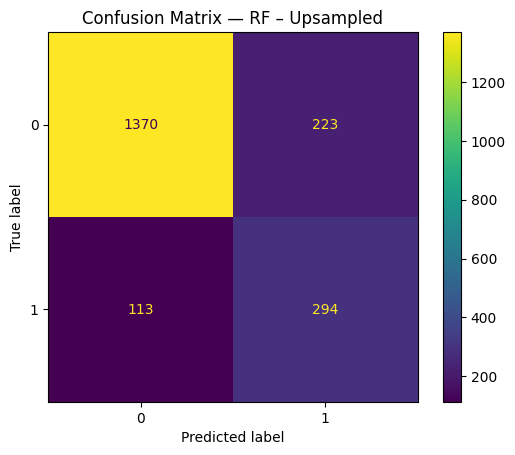

── Random Forest Downsampled ──

Best RF – Downsampled Performance:


,Score
F1 Score,0.609524
ROC AUC,0.863224
Accuracy,0.795000
Log Loss,0.466994



Best params:


,Best Value
model__n_estimators,200
model__max_depth,10
model__class_weight,balanced


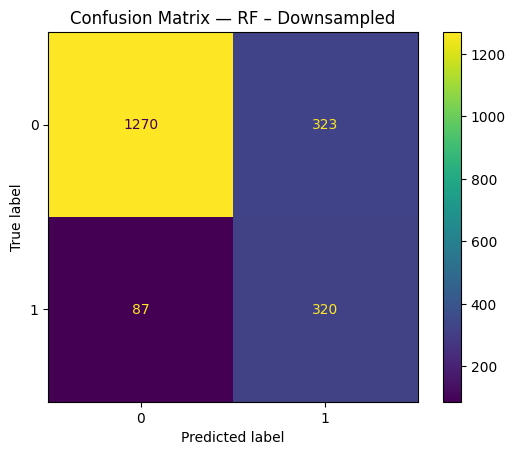

In [16]:
rf_raw, rf_up, rf_down = make_pipelines(
    preprocessor_rf,
    RandomForestClassifier(random_state=12345)
)

param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth':    [5, 10, 15, 20],
    'model__class_weight': ['balanced', None]
}

print("── Random Forest Raw ──")
rf_raw_results, rf_raw_params, rf_raw_best = train_with_search(
    rf_raw, param_grid_rf, X_train, X_test, y_train, y_test, model_name='RF – Raw')

print("── Random Forest Upsampled ──")
rf_up_results, rf_up_params, rf_up_best = train_with_search(
    rf_up, param_grid_rf, X_train, X_test, y_train, y_test, model_name='RF – Upsampled')

print("── Random Forest Downsampled ──")
rf_down_results, rf_down_params, rf_down_best = train_with_search(
    rf_down, param_grid_rf, X_train, X_test, y_train, y_test, model_name='RF – Downsampled')

Random Forest outperforms Logistic Regression substantially across all three variants, confirming that the relationships in this dataset are non-linear and benefit from a more flexible model.

All three variants converge on the same best parameters: 200 estimators, max depth of 10, and balanced class weights. This consistency suggests the search found a genuinely stable optimum rather than a coincidence.

The key tradeoff between variants is precision vs. recall:

1. Raw achieves the second highest F1 (0.628) but misses 139 churners, the worst false negative count of the three.
2. Upsampled achieves the highest F1 (0.636) and a strong ROC-AUC of 0.863, but still misses 113 churners.
3. Downsampled has the lowest F1 (0.609) but catches the most churners, with only 87 false negatives, while maintaining the same ROC-AUC of 0.863 as the upsampled variant.


In [17]:
# Results summary.

all_results = {
    'LR – Raw':           lr_raw_results,
    'LR – Upsampled':     lr_up_results,
    'LR – Downsampled':   lr_down_results,
    'RF – Raw':           rf_raw_results,
    'RF – Upsampled':     rf_up_results,
    'RF – Downsampled':   rf_down_results,
}

records = []

for name, result in all_results.items():
    model, sampling = name.split(' – ')

    records.append({
        'Model': model,
        'Sampling': sampling,
        'F1 Score': result['F1 Score'],
        'ROC AUC': result['ROC AUC'],
        'Accuracy': result['Accuracy'],
        'Log Loss': result['Log Loss']
    })

summary = pd.DataFrame(records)

summary = summary.sort_values('F1 Score', ascending=False)

display(summary)

,Model,Sampling,F1 Score,ROC AUC,Accuracy,Log Loss
4,RF,Upsampled,0.636364,0.863289,0.8320,0.414623
3,RF,Raw,0.628370,0.864725,0.8415,0.392993
5,RF,Downsampled,0.609524,0.863224,0.7950,0.466994
2,LR,Downsampled,0.512777,0.781379,0.7140,0.580427
1,LR,Upsampled,0.511548,0.782389,0.7145,0.579916
0,LR,Raw,0.509771,0.781850,0.7115,0.581437


Two models were evaluated: Logistic Regression and Random Forest, each tested using three sampling strategies (raw data, upsampling, and downsampling). Logistic Regression consistently underperformed, with an average F1 score of around 0.51. In contrast, Random Forest delivered significantly stronger results across all strategies.

Although the Random Forest with upsampling achieved the highest F1 score (0.636), the downsampled version was selected as the final model. The project prioritizes identifying customers at risk of leaving, since retaining existing customers is more cost-effective than acquiring new ones. For this reason, minimizing false negatives is critical. The downsampled model produced the lowest number of false negatives (87) while maintaining a strong ROC-AUC score of 0.863, making it the most aligned with the business objective.

## PR Curve

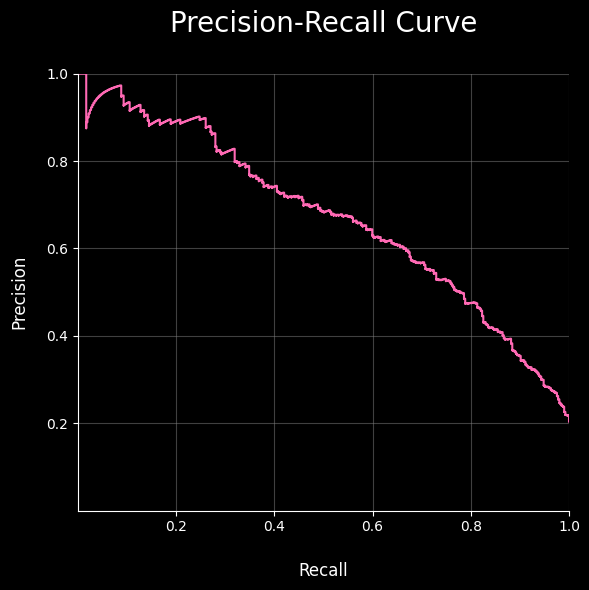

In [18]:
from sklearn.metrics import precision_recall_curve

y_proba = rf_down_best.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(
    y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.step(recalls, precisions, where='post', color='hotpink')
plt.xlabel('Recall', color='white', labelpad=20, fontsize=12)
plt.ylabel('Precision', color='white', labelpad=13, fontsize=12)
plt.title('Precision-Recall Curve', color='white', pad=30, fontsize=20)

plt.xlim([0, 1])
plt.ylim([0, 1])

plt.xticks(np.linspace(0.2, 1, 5))
plt.yticks(np.linspace(0.2, 1, 5))

plt.gca().set_facecolor('black')
plt.gcf().patch.set_facecolor('black')
plt.gca().tick_params(colors='white')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('white')
plt.gca().spines['bottom'].set_color('white')

plt.grid(True, alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

The curve holds above 0.8 precision through a recall of roughly 0.4, meaning the model can correctly identify 40% of all churners while still being right about 80% of the time when it flags someone. Beyond that point the curve degrades more steadily, which is expected behavior as the model is forced to cast a wider net to catch more churners.


## ROC Curve

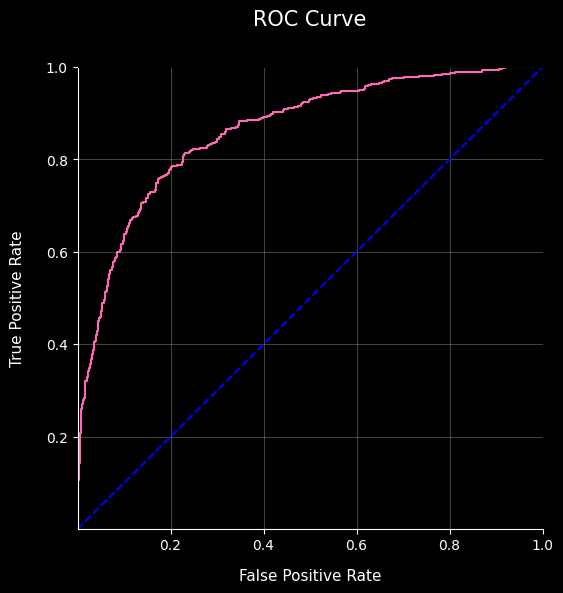

In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr, color='hotpink')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--')

plt.ylim([0, 1])
plt.xlim([0, 1])

plt.yticks(np.linspace(0.2, 1.0, 5))
plt.xticks(np.linspace(0.2, 1.0, 5))

plt.gca().set_facecolor('black')
plt.gcf().patch.set_facecolor('black')
plt.gca().tick_params(colors='white')

plt.gca().spines['left'].set_color('white')
plt.gca().spines['bottom'].set_color('white')

plt.xlabel('False Positive Rate', color='white', labelpad=11, fontsize=11)
plt.ylabel('True Positive Rate', color='white', labelpad=15, fontsize=11)
plt.title('ROC Curve', color='white', pad=30, fontsize=15)
plt.grid(True, alpha=0.5, color='gray')
plt.show()

The curve rises steeply in the early portion, meaning the model captures a large share of churners before accumulating many false positives. By the time the false positive rate reaches 0.2, the model has already identified roughly 80% of all actual churners, which is a strong result in practice.

The ROC-AUC of 0.863 confirms that if the model were given one real churner and one non-churner at random, it would rank the churner as higher risk 86.3% of the time. This makes it a reliable discriminator even before any threshold decisions are made, and gives confidence that the model's performance is not simply a product of the class imbalance but reflects genuine predictive signal in the features.

## Threshold selection

In [20]:
# Improving threshold selection for the Random Forest model by maximizing the Recall score.

precisions, recalls, thresholds = precision_recall_curve(
    y_test, y_proba)

min_precision = 0.5
mask = precisions[:-1] >= min_precision
best_threshold = thresholds[mask][recalls[:-1][mask].argmax()]

print(
    f"Best threshold for Recall (min precision {min_precision}): {best_threshold:.3f}")

Best threshold for Recall (min precision 0.5): 0.506


,Score
F1 Score,0.609030
ROC AUC,0.863224
Accuracsy,0.796500
Log Loss,0.466994


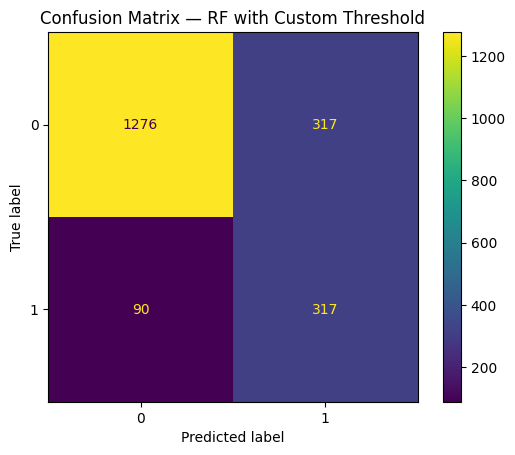

In [21]:
y_pred_threshold = (y_proba >= best_threshold).astype(int)

results_threshold = {
    'F1 Score': f1_score(y_test, y_pred_threshold),
    'ROC AUC':  roc_auc_score(y_test, y_proba),
    'Accuracsy': accuracy_score(y_test, y_pred_threshold),
    'Log Loss': log_loss(y_test, y_proba)
}

display(pd.DataFrame(results_threshold.values(),
        index=results_threshold.keys(), columns=['Score']))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_threshold)).plot()
plt.title('Confusion Matrix — RF with Custom Threshold')
plt.show()

Threshold tuning was attempted to further reduce false negatives by shifting the classification cutoff away from the default 0.5. The precision-recall curve was used to find the threshold that maximized recall while keeping precision at or above 0.5. This yielded a threshold of 0.506, but the result was worse: false negatives increased from 87 to 90, with no meaningful gain elsewhere. The original model's default threshold was already well-calibrated for the business objective, and further adjustment introduced more misses rather than fewer. The Random Forest Downsampled model with default threshold was therefore kept as the final selection.

## Feature Importance

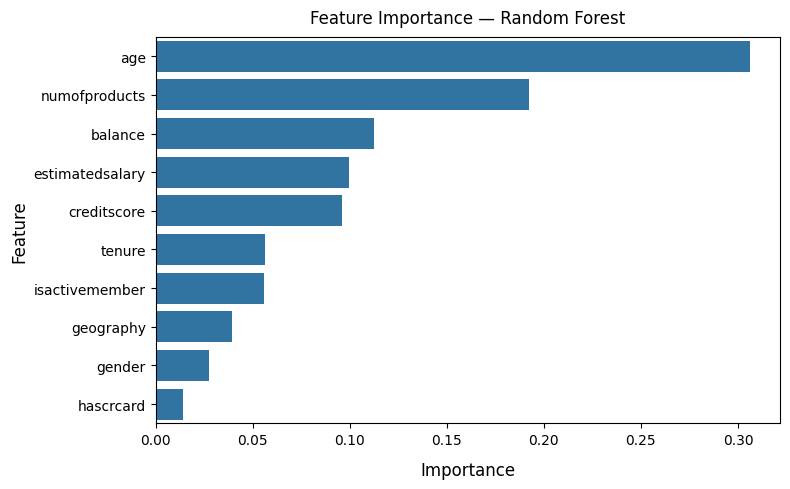

In [72]:
preprocessor = rf_down_best.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
importances = rf_down_best.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp['feature'] = feat_imp['feature'].str.replace(
    'ordinal__', '').str.replace('num__', '')

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title('Feature Importance — Random Forest', pad=10)
plt.xlabel('Importance', fontsize=12, labelpad=10)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

Age is the dominant predictor at roughly 30%, followed by number of products at 19% and balance at 11%, all consistent with the EDA findings. Estimated salary and credit score contribute moderately despite showing little visual separation in the KDE plots, suggesting the model extracts value from them in combination with other features. Having a credit card is the least informative feature, again aligning with the categorical analysis. Overall, age and number of products are the primary drivers, and any retention strategy should prioritize targeting customers based on those two variables first.

In [24]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 3376 to 7549
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   creditscore      8000 non-null   int64  
 1   geography        8000 non-null   str    
 2   gender           8000 non-null   str    
 3   age              8000 non-null   int64  
 4   tenure           8000 non-null   float64
 5   balance          8000 non-null   float64
 6   numofproducts    8000 non-null   int64  
 7   hascrcard        8000 non-null   int64  
 8   isactivemember   8000 non-null   int64  
 9   estimatedsalary  8000 non-null   float64
dtypes: float64(3), int64(5), str(2)
memory usage: 687.5 KB


In [22]:
X_train.sample(5, random_state=23)

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary
5688,471,Germany,Male,23,6.0,104592.55,2,1,0,131736.23
3987,633,France,Male,37,5.0,141546.35,1,1,1,124830.11
2241,681,Germany,Male,42,3.0,118199.97,2,1,0,9452.88
7162,607,Spain,Male,34,9.0,132439.99,1,1,0,177747.72
864,594,France,Male,38,4.0,0.00,2,0,0,186884.04


In [23]:
y_train[X_train.index == 2241]

2241    1
Name: exited, dtype: int64

# Conclusion

This project set out to predict customer churn for a bank using demographic and account data. After evaluating Logistic Regression and Random Forest across three sampling strategies, the Random Forest Downsampled model was selected as the final model. It achieved an F1 score of 0.609 and a ROC-AUC of 0.863, with only 87 false negatives, the lowest of all variants tested. Threshold tuning was explored but ultimately did not improve on the default behavior, confirming the model was already well-calibrated for the business objective. Given that retaining a customer is more cost-effective than acquiring a new one, minimizing missed churners was the guiding criterion throughout, and the selected model reflects that priority.